In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

from sarimax import plot_target
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima.arima import auto_arima




In [31]:
#Prepare data
from pathlib import Path

data_dir = Path.cwd() / "Data"
cordata = pd.read_csv(data_dir / "cordata_upd.csv")
macro = pd.read_csv(data_dir / "disaggregated.csv")
dummy = pd.read_csv(data_dir / "dummy.csv")

macro = macro.rename(columns = {"Unnamed: 3": "Date"})
features = pd.merge(macro, dummy, on="Date", how="left")
dummy_cols = [c for c in dummy.columns if c != "Date"]
features[dummy_cols] = features[dummy_cols].fillna(0)

target = cordata[["Date", "BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures"]]
features = features[["Date", "Inflation", "Imports", "Exports", "USDPHP", "NominalGDP_disagg", "Pop_disagg", 
                     "COVID-19", "TRAIN","CREATE","FIST","BIR_COMM"]]
target["Tax Revenues"] = target[["BIR", "BOC", "Other Offices"]].sum(axis=1)

# Convert Date to datetime
target["Date"] = pd.to_datetime(target["Date"])
features["Date"] = pd.to_datetime(features["Date"] )

num_cols = ["BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures"]
for c in num_cols:
    target[c] = pd.to_numeric(target[c].astype(str).str.replace(",", "", regex=False), errors="coerce")

target["Tax Revenues"] = target[["BIR", "BOC", "Other Offices"]].sum(axis=1)

# Filter both to start from 1992-01-01
target = target[target["Date"] >= "1992-01-01"]
features = features[features["Date"] >= "1992-01-01"]

target = target.set_index("Date")
features = features.set_index("Date")

# Replace NaN values with 0
features = features.fillna(0)

# Convert target and features to quarterly data
target_q = target.resample("QE-DEC").sum()

feature_agg = {col: "sum" for col in features.columns}
for col in ["COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]:
    if col in feature_agg:
        feature_agg[col] = "max"
for col in ["Inflation", "USDPHP", "NominalGDP_disagg", "Pop_disagg"]:
    if col in feature_agg:
        feature_agg[col] = "mean"

features_q = features.resample("QE-DEC").agg(feature_agg)

print("Quarterly target shape:", target.shape)
print("Quarterly features shape:", features.shape)

Quarterly target shape: (408, 6)
Quarterly features shape: (396, 11)


In [32]:
target

,BIR,BOC,Other Offices,Non-tax Revenues,Expenditures,Tax Revenues
Date,,,,,,
1992-01-01,15661.0,6286.0,174.0,2508.0,25134.0,22121.0
1992-02-01,7731.0,5757.0,152.0,2313.0,18752.0,13640.0
1992-03-01,7975.0,7872.0,171.0,4912.0,12600.0,16018.0
1992-04-01,19322.0,5724.0,143.0,1441.0,21690.0,25189.0
1992-05-01,7625.0,5153.0,136.0,2625.0,21277.0,12914.0
...,...,...,...,...,...,...
2025-08-01,250112.0,77436.0,3692.0,21275.0,437283.0,331240.0
2025-09-01,182961.0,80284.0,2659.0,15812.0,529796.0,265904.0
2025-10-01,328842.0,82962.0,2697.0,27213.0,430560.0,414501.0


In [33]:
target_q.reset_index()

,Date,BIR,BOC,Other Offices,Non-tax Revenues,Expenditures,Tax Revenues
0,1992-03-31,31367.0,19915.0,497.0,9733.0,56486.0,51779.0
1,1992-06-30,36571.0,16811.0,363.0,6540.0,61418.0,53745.0
2,1992-09-30,32378.0,16199.0,512.0,9285.0,67829.0,49089.0
3,1992-12-31,33588.0,19945.0,559.0,8451.0,72947.0,54092.0
4,1993-03-31,33625.0,16671.0,349.0,7423.0,68394.0,50645.0
...,...,...,...,...,...,...,...
131,2024-12-31,756969.0,225998.0,5857.0,137286.0,1662244.0,988824.0
132,2025-03-31,690409.0,231378.0,9733.0,66647.0,1444196.0,931520.0
133,2025-06-30,863755.0,227393.0,9845.0,161058.0,1581515.0,1100993.0
134,2025-09-30,768327.0,242900.0,8913.0,86367.0,1458272.0,1020140.0


In [25]:
target

,BIR,BOC,Other Offices,Non-tax Revenues,Expenditures,Tax Revenues
Date,,,,,,
1992-01-01,15661.0,6286.0,174.0,2508.0,25134.0,22121.0
1992-02-01,7731.0,5757.0,152.0,2313.0,18752.0,13640.0
1992-03-01,7975.0,7872.0,171.0,4912.0,12600.0,16018.0
1992-04-01,19322.0,5724.0,143.0,1441.0,21690.0,25189.0
1992-05-01,7625.0,5153.0,136.0,2625.0,21277.0,12914.0
...,...,...,...,...,...,...
2025-08-01,NaN,NaN,NaN,NaN,NaN,0.0
2025-09-01,NaN,NaN,NaN,NaN,NaN,0.0
2025-10-01,NaN,NaN,NaN,NaN,NaN,0.0


In [37]:
target_q.to_csv("quarterly.csv", index=True)

In [45]:
TARGETS = {
    "aggregated": {
        "features": ["Non-tax Revenues", "Expenditures","Tax Revenues", "TotalTrade_PHPMN", "NominalGDP_disagg", "Pop_disagg", "USDPHP"],
        "labels":   ["Tax Revenues","Non-tax Revenues", "Expenditures"],
        # BIR+BOC+Others collapsed into one "Tax Revenues" column in your cordata.csv
        # If you have an aggregated tax col, add it to features/labels above
    },
    "disaggregated": {
        "features": ["BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures",
                     "TotalTrade_PHPMN", "NominalGDP_disagg", "Pop_disagg", "USDPHP"],
        "labels":   ["BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures"],
    },
}

FEATURE_CONFIGS = {
    # Config 1: All numerical + lagged + dummy
    "num_lag_dummy": {
        "dummy_vars":    ["COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"],
        "use_seasonal":  False,
    },
    # Config 2: All numerical + lagged + COVID-19 only
    "num_lag_covid": {
        "dummy_vars":    ["COVID-19"],
        "use_seasonal":  False,
    },
    # Config 3: All numerical + lagged + dummy + seasonal
    "num_lag_dummy_seasonal": {
        "dummy_vars":    ["COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"],
        "use_seasonal":  True,
    },
    # Config 4: All numerical + lagged + COVID-19 + seasonal
    "num_lag_covid_seasonal": {
        "dummy_vars":    ["COVID-19"],
        "use_seasonal":  True,
    },
}

In [46]:
target

,BIR,BOC,Other Offices,Non-tax Revenues,Expenditures,Tax Revenues
Date,,,,,,
2007-03-31,143108,40221,2745,51229.0,289271.0,186074
2007-06-30,191610,51936,2817,26613.0,261989.0,246363
2007-09-30,187202,60800,2536,51440.0,301007.0,250538
2007-12-31,191685,56482,1795,74341.0,296734.0,249962
2008-03-31,166622,48880,2423,35591.0,305075.0,217925
...,...,...,...,...,...,...
2023-12-31,658957,222826,5664,98834.0,1514893.0,887447
2024-03-31,591769,218852,9745,113374.0,1206384.0,820366
2024-06-30,770252,236666,8086,200805.0,1557072.0,1015004


In [47]:
def plot_target(df, target: str, figsize=(10, 5), color='green', linewidth=1):

    x = df.index
    y = df[target] 

    plt.figure(figsize=figsize)
    plt.title(f'Monthly {target} (2000 - 2025Q2)', fontsize=14)  
    plt.plot(x, y, color=color, linewidth=linewidth)

    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.xlabel("Year")
    plt.ylabel(target) 
    plt.xticks(rotation=45, fontsize=10)

    plt.tight_layout()
    plt.show()

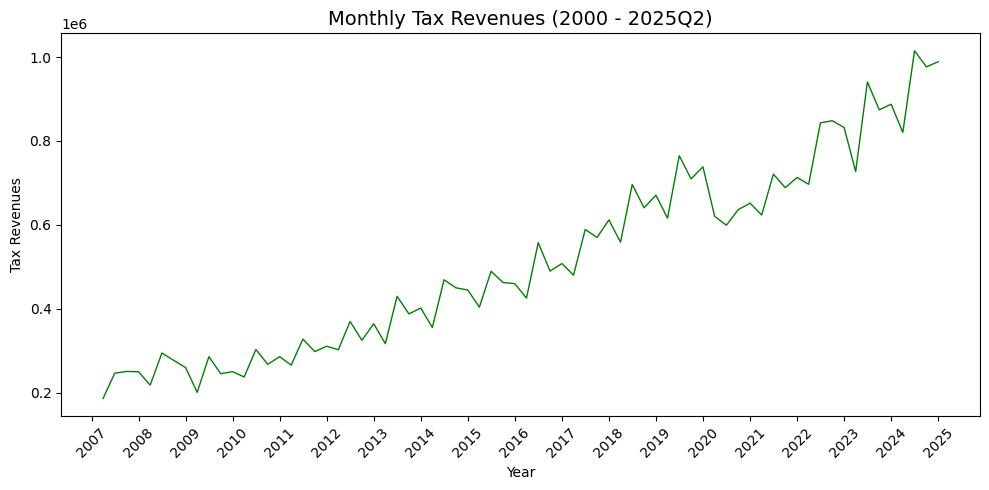

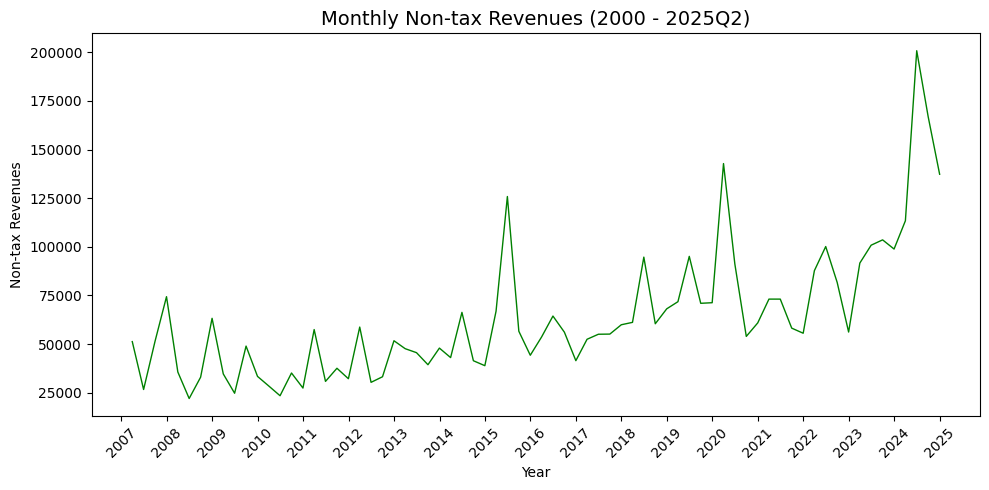

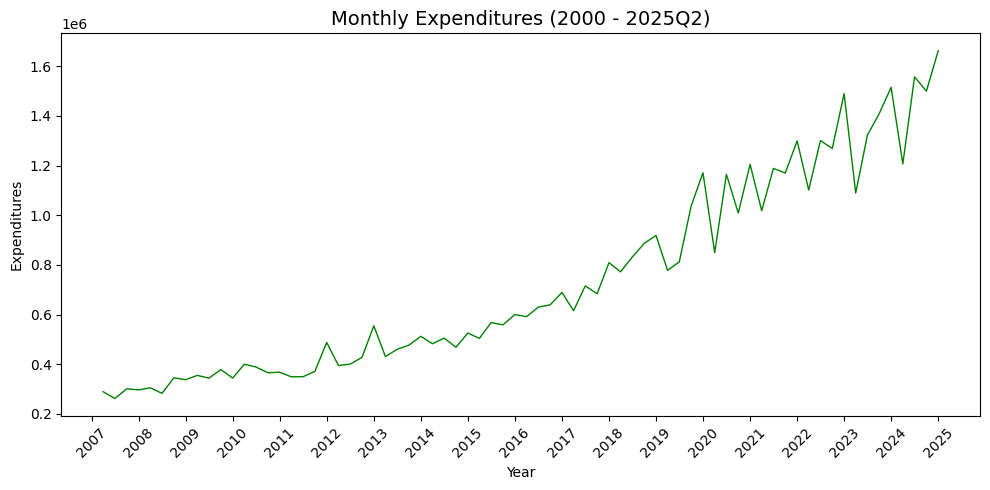

In [48]:
for x in TARGETS["aggregated"]["labels"]:
    plot_target(target, x)

In [49]:
# Split data
test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

train = target[:train_size]
test = target[train_size:]

test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

feat_train = features[:train_size]
feat_test = features[train_size:]


In [34]:
records = []

for x in TARGETS["aggregated"]["labels"]:
    level = adfuller(train[x].dropna())
    first_diff = adfuller(train[x].diff().dropna())
    second_diff = adfuller(train[x].diff().diff().dropna())
    seasonal_diff = adfuller(train[x].diff(12).dropna())           # D=1, s=12
    seasonal_double_diff = adfuller(train[x].diff().diff(12).dropna())  # d=1, D=1, s=12

    records.append({
        'Variable': x,
        'Level p-value': round(level[1], 4),
        'Level Stationary': level[1] < 0.05,
        'First Diff p-value': round(first_diff[1], 4),
        'First Diff Stationary': first_diff[1] < 0.05,
        'Second Diff p-value': round(second_diff[1], 4),
        'Second Diff Stationary': second_diff[1] < 0.05,
        'Seasonal Diff p-value': round(seasonal_diff[1], 4),
        'Seasonal Diff Stationary': seasonal_diff[1] < 0.05,
        'Seasonal Double Diff p-value': round(seasonal_double_diff[1], 4),
        'Seasonal Double Diff Stationary': seasonal_double_diff[1] < 0.05,
    })

pd.DataFrame(records).set_index('Variable')

,Level p-value,Level Stationary,First Diff p-value,First Diff Stationary,Second Diff p-value,Second Diff Stationary,Seasonal Diff p-value,Seasonal Diff Stationary,Seasonal Double Diff p-value,Seasonal Double Diff Stationary
Variable,,,,,,,,,,
Tax Revenues,0.9991,False,0.5238,False,0.0,True,0.9297,False,0.0041,True
Non-tax Revenues,0.8444,False,0.0000,True,0.0,True,0.0075,True,0.1380,False
Expenditures,1.0000,False,0.0086,True,0.0,True,0.9989,False,0.5657,False


### Order Specification

In [50]:
diff_tax_train = train["Tax Revenues"].diff().diff(4).dropna()
diff_nontax_train = train["Non-tax Revenues"].diff().dropna()
diff_expenditure_train = train['Expenditures'].diff().dropna()

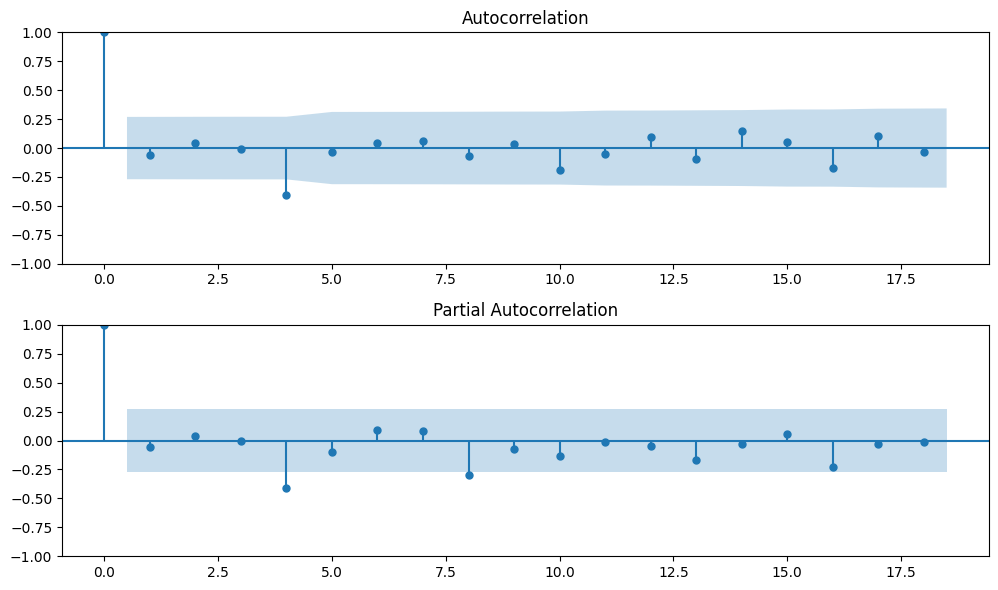

In [51]:
#Tax
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_tax_train).dropna(), ax=ax[0])
plot_pacf((diff_tax_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

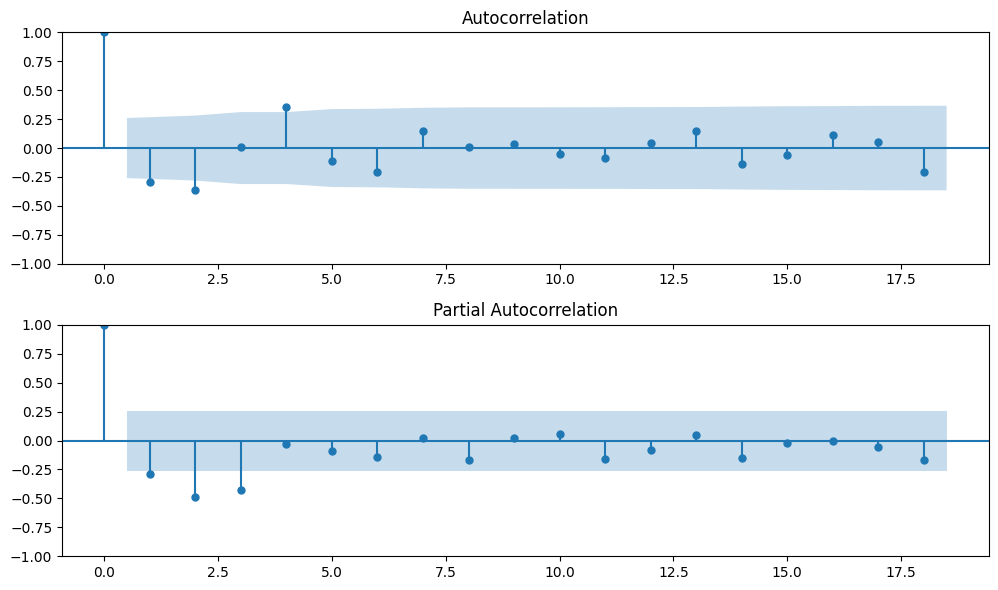

In [52]:
#NonTax
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_nontax_train).dropna(), ax=ax[0])
plot_pacf((diff_nontax_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

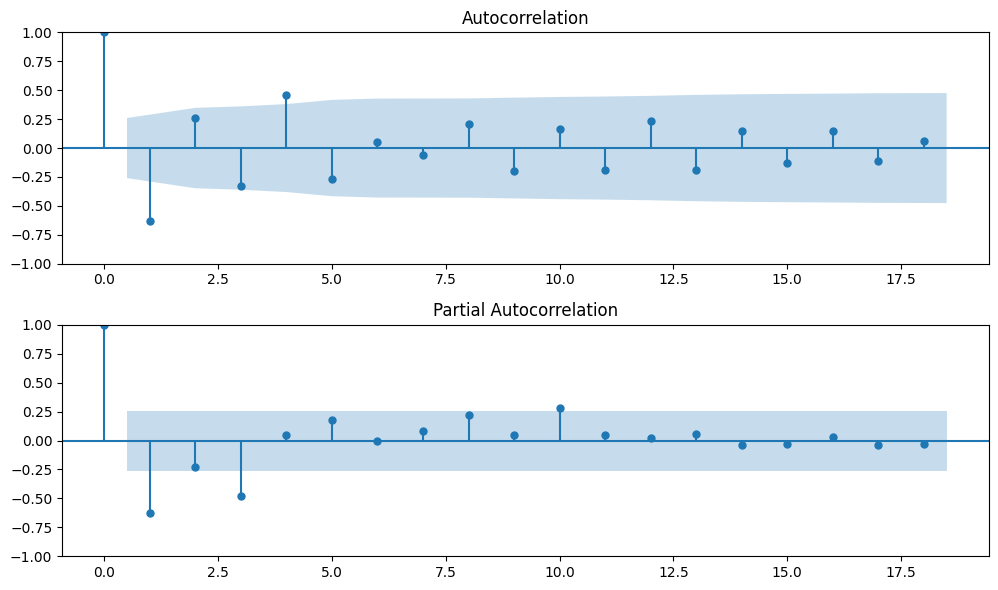

In [53]:
#Expenditures Train
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_expenditure_train).dropna(), ax=ax[0])
plot_pacf((diff_expenditure_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

In [ ]:
#Final Orders
#Tax Revenues ()

### SARIMA (No exog variables)

In [54]:
tax_train = train["Tax Revenues"]
nontax_train = train["Non-tax Revenues"]
expenditure_train = train['Expenditures']
tax_test = test["Tax Revenues"]
nontax_test = test["Non-tax Revenues"]
expenditure_test = test['Expenditures']

In [56]:
model = auto_arima(tax_train, start_p=0, start_d=1, start_q=0,
                           max_p=0, max_d=1, max_q=0, 
                           seasonal=True,
                           start_P= 2, start_D=1, start_Q =1,
                           max_P = 2, max_D = 1, max_Q=1,
                           error_action='warn', trace=False,
                           suppress_warnings=True, stepwise=False,
                           exog=None,
                           maxiter=100, method='powell')


model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   58
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -707.199
Date:                Sat, 21 Feb 2026   AIC                           1418.399
Time:                        13:41:43   BIC                           1422.485
Sample:                    03-31-2007   HQIC                          1419.987
                         - 06-30-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   9381.4915   8862.917      1.059      0.290   -7989.507    2.68e+04
sigma2        3.5e+09   8.16e+08      4.287      0.000     1.9e+09     5.1e+09
===================================================================================
Ljung-Box (L1) (Q):                  20.81   Jarque-Bera (JB):                 3.71
Prob(Q):                              0.00   Prob(JB):                         0.16
Heteroskedasticity (H):               2.73   Skew:                             0.60
Prob(H) (two-sided):                  0.03   Kurtosis:                         2.65
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [57]:
model_sarima = SARIMAX(train['Tax Revenues'],
order=(0, 1, 0), # (p,d,q)
seasonal_order=(2, 1, 1, 4)) # (P,D,Q,s)
results_sarima = model_sarima.fit(disp=False)
print(results_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                        Tax Revenues   No. Observations:                   58
Model:             SARIMAX(0, 1, 0)x(2, 1, [1], 4)   Log Likelihood                -631.333
Date:                             Sat, 21 Feb 2026   AIC                           1270.666
Time:                                     13:41:55   BIC                           1278.547
Sample:                                 03-31-2007   HQIC                          1273.696
                                      - 06-30-2021                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L4       -0.8951      0.272     -3.295      0.001      -1.428      -0.363
ar.S.L8       -0.4130      

In [58]:
#Forecasting
forecast_steps = len(test)
forecast_result = results_sarima.get_forecast(steps=forecast_steps)
# Predicted mean values
forecast_sarima = forecast_result.predicted_mean
# Confidence intervals (optional)
conf_int = forecast_result.conf_int()



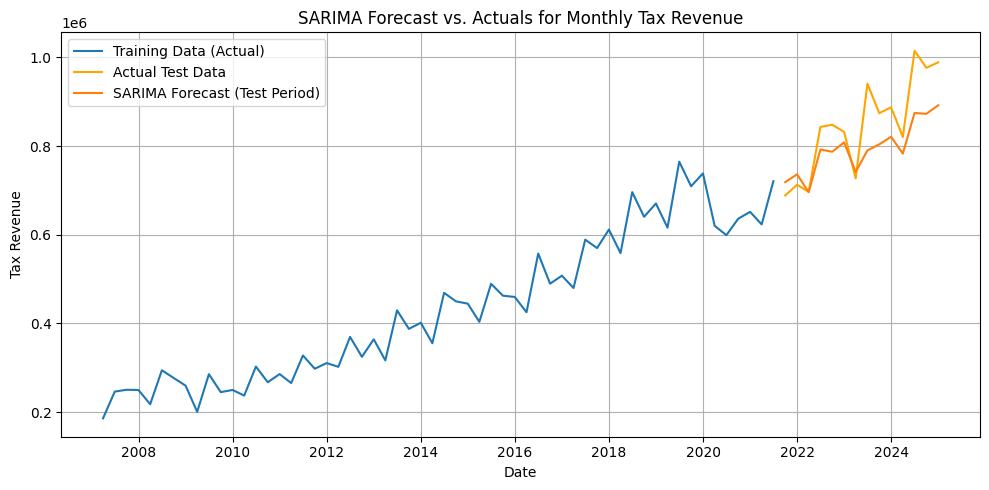

In [59]:
plt.figure(figsize=(10, 5))
# Plot training data
# Ensure 'train_data' is a Series with a DatetimeIndex
plt.plot(tax_train.index, tax_train, label='Training Data (Actual)')
# Plot actual test data points
# Ensure 'test_data' is a Series with a DatetimeIndex
plt.plot(tax_test.index, tax_test, label='Actual Test Data', color='orange')
# Ensure 'forecast' is a Series with a DatetimeIndex
plt.plot(forecast_sarima.index, forecast_sarima, label='SARIMA Forecast (Test Period)')
plt.title('SARIMA Forecast vs. Actuals for Monthly Tax Revenue')
plt.xlabel('Date')
plt.ylabel('Tax Revenue')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [60]:
mae = mean_absolute_error(tax_test, forecast_sarima)
rmse = np.sqrt(mean_squared_error(tax_test, forecast_sarima))
mape = np.mean(np.abs((tax_test - forecast_sarima)/ tax_test)*100)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 62116.51
Root Mean Squared Error (RMSE): 76425.93
Mean Absolute Percentage Error (MAPE): 6.87%


### With Covid 

In [20]:
covid_train = feat_train["COVID-19"]
covid_test = feat_test["COVID-19"]

In [21]:
# Dates in target but missing in features
missing_in_features = target.index.difference(features.index)

print(f"Missing in features: {len(missing_in_features)}")
print(missing_in_features[:20])  # first 20

Missing in features: 0
DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq='QE-DEC')


In [22]:
model = auto_arima(tax_train, start_p=0, start_d=1, start_q=0,
                           max_p=2, max_d=1, max_q=1, 
                           seasonal=True,
                           start_P= 1, start_D=1, start_Q =1,
                           max_P = 1, max_D = 1, max_Q=1,
                           error_action='warn', trace=False,
                           suppress_warnings=True, stepwise=False,
                           exog=covid_train,
                           maxiter=100, method='powell')


model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  106
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1226.442
Date:                Sat, 21 Feb 2026   AIC                           2460.883
Time:                        13:36:01   BIC                           2471.499
Sample:                    03-31-1992   HQIC                          2465.185
                         - 06-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   8131.7170   1512.484      5.376      0.000    5167.302    1.11e+04
ar.L1         -0.4459      0.106     -4.226      0.000      -0.653      -0.239
ma.L1         -0.4593      0.117     -3.921      0.000      -0.689      -0.230
sigma2      8.172e+08      0.012   6.69e+10      0.000    8.17e+08    8.17e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                26.27
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):              11.30   Skew:                             0.85
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.17e+25. Standard errors may be unstable.
"""

In [24]:
model_sarima_covid = SARIMAX(tax_train,
order=(1, 1, 1), # (p,d,q)
seasonal_order=(1, 1, 1, 4),
exog=covid_train) # (P,D,Q,s)
results_sarima_covid = model_sarima_covid.fit(disp=False)
print(results_sarima_covid.summary())

                                     SARIMAX Results                                     
Dep. Variable:                      Tax Revenues   No. Observations:                  106
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood               -1109.223
Date:                           Sat, 21 Feb 2026   AIC                           2230.446
Time:                                   13:36:13   BIC                           2246.137
Sample:                               03-31-1992   HQIC                          2236.798
                                    - 06-30-2018                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
COVID-19            0    1.2e-09          0      1.000   -2.35e-09    2.35e-09
ar.L1         -0.0094      0.247     -0.038

In [25]:
#Forecasting
forecast_steps = len(test)
forecast_result_covid = results_sarima_covid.get_forecast(steps=forecast_steps, exog=covid_test)
# Predicted mean values
forecast_sarima_covid = forecast_result_covid.predicted_mean
# Confidence intervals (optional)
conf_int = forecast_result_covid.conf_int()

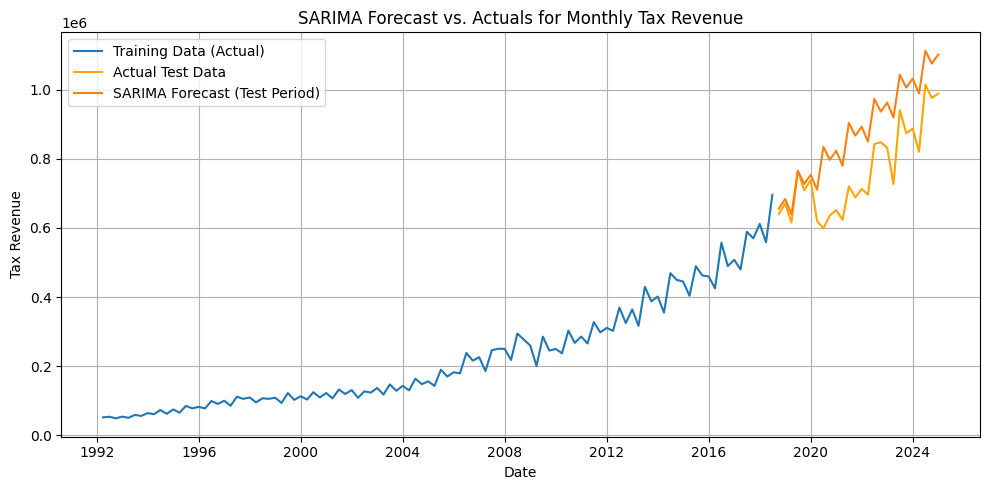

In [26]:
plt.figure(figsize=(10, 5))
# Plot training data
# Ensure 'train_data' is a Series with a DatetimeIndex
plt.plot(tax_train.index, tax_train, label='Training Data (Actual)')
# Plot actual test data points
# Ensure 'test_data' is a Series with a DatetimeIndex
plt.plot(tax_test.index, tax_test, label='Actual Test Data', color='orange')
# Ensure 'forecast' is a Series with a DatetimeIndex
plt.plot(forecast_sarima.index, forecast_sarima_covid, label='SARIMA Forecast (Test Period)')
plt.title('SARIMA Forecast vs. Actuals for Monthly Tax Revenue')
plt.xlabel('Date')
plt.ylabel('Tax Revenue')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mae = mean_absolute_error(tax_test, forecast_sarima_covid)
rmse = np.sqrt(mean_squared_error(tax_test, forecast_sarima_covid))
mape = np.mean(np.abs((tax_test - forecast_sarima_covid)/ tax_test)*100)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 115351.93
Root Mean Squared Error (RMSE): 132389.46
Mean Absolute Percentage Error (MAPE): 0.16%


### With Macro

In [117]:
macro_train = feat_train[["Imports","Exports", "NominalGDP_disagg", "Pop_disagg", "USDPHP"]]
macro_test = feat_test[["Imports","Exports", "NominalGDP_disagg", "Pop_disagg", "USDPHP"]]

In [118]:
model_macro = auto_arima(tax_train, start_p=0, start_d=1, start_q=0,
                           max_p=3, max_d=1, max_q=1, 
                           seasonal=True,
                           start_P= 1, start_D=1, start_Q =1,
                           max_P = 1, max_D = 1, max_Q=1,
                           error_action='warn', trace=False,
                           suppress_warnings=True, stepwise=False,
                           exog=macro_train,
                           maxiter=100, method='powell')


model_macro.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  317
Model:               SARIMAX(2, 1, 1)   Log Likelihood               -3448.436
Date:                Fri, 20 Feb 2026   AIC                           6906.872
Time:                        18:39:02   BIC                           6925.651
Sample:                    01-01-1992   HQIC                          6914.374
                         - 05-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1001.4457    197.423      5.073      0.000     614.504    1388.388
ar.L1         -0.1022      0.049     -2.072      0.038      -0.199      -0.006
ar.L2         -0.5027      0.039    -12.971      0.000      -0.579      -0.427
ma.L1         -0.7576      0.034    -22.226      0.000      -0.824      -0.691
sigma2      1.756e+08      0.001   1.26e+11      0.000    1.76e+08    1.76e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):               244.05
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               9.44   Skew:                             0.84
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.18e+26. Standard errors may be unstable.
"""

In [119]:
model_sarima_macro = SARIMAX(tax_train,
order=(2, 1, 1), # (p,d,q)
seasonal_order=(1, 1, 1, 12),
exog=macro_train) # (P,D,Q,s)
results_sarima_macro = model_sarima_macro.fit(disp=False)
print(results_sarima_macro.summary())

C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                       Tax Revenues   No. Observations:                  317
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3077.305
Date:                            Fri, 20 Feb 2026   AIC                           6176.611
Time:                                    18:39:54   BIC                           6217.498
Sample:                                01-01-1992   HQIC                          6192.967
                                     - 05-01-2018                                         
Covariance Type:                              opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Imports               6.3103      0.807      7.816      0.000       4.728       7.893
Exports       

C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [120]:
#Forecasting
forecast_steps = len(test)
forecast_result_macro = results_sarima_macro.get_forecast(steps=forecast_steps, exog=macro_test)
# Predicted mean values
forecast_sarima_macro = forecast_result_macro.predicted_mean
# Confidence intervals (optional)
conf_int = forecast_result_macro.conf_int()

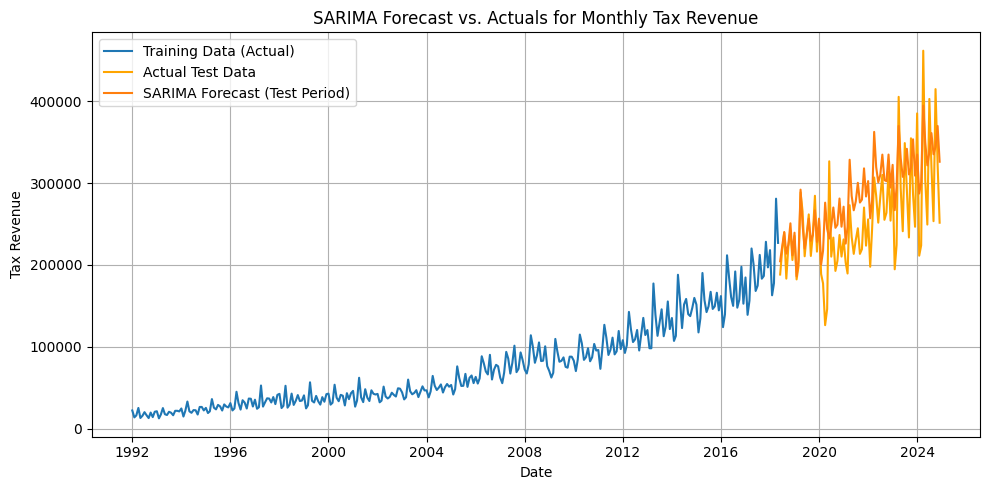

In [121]:
plt.figure(figsize=(10, 5))
# Plot training data
# Ensure 'train_data' is a Series with a DatetimeIndex
plt.plot(tax_train.index, tax_train, label='Training Data (Actual)')
# Plot actual test data points
# Ensure 'test_data' is a Series with a DatetimeIndex
plt.plot(tax_test.index, tax_test, label='Actual Test Data', color='orange')
# Ensure 'forecast' is a Series with a DatetimeIndex
plt.plot(forecast_sarima.index, forecast_sarima_macro, label='SARIMA Forecast (Test Period)')
plt.title('SARIMA Forecast vs. Actuals for Monthly Tax Revenue')
plt.xlabel('Date')
plt.ylabel('Tax Revenue')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [122]:
mae = mean_absolute_error(tax_test, forecast_sarima_macro)
rmse = np.sqrt(mean_squared_error(tax_test, forecast_sarima_macro))
mape = np.mean(np.abs((tax_test - forecast_sarima_macro)/ tax_test))
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 41791.31
Root Mean Squared Error (RMSE): 50038.84
Mean Absolute Percentage Error (MAPE): 0.18%
